# FlagGAM Guidebook — German Credit scorecard

FlagGAM fits an additive scorecard from **rule bases** — thresholds, hinges, trends, and category indicators discovered directly from the training data — rather than from arbitrary black-box splits. Every prediction decomposes into a sum of named-rule contributions, so it is auditable end to end: you can list the rules, explain a single decision, calibrate the probabilities, enforce a monotonic direction on a feature, and audit for proxy bias.

This notebook walks through that full workflow on the UCI Statlog German Credit dataset (1000 applicants, binary good/bad credit label):

1. Setup — load the data, split, check class balance.
2. Fit and inspect the rule basis.
3. Reason codes for a single applicant.
4. Probability calibration.
5. Monotonicity constraints.
6. Fairness and proxy audit.
7. Summary and API pointers.

## 1. Setup

German Credit ships from `flaggam.datasets` with raw UCI attribute codes (`Attribute1` … `Attribute20`); we rename them to the documented Statlog field names below for readability (only the labels change, not the values), then hold out a stratified test split so the AUROC estimate below is stable across the two credit-risk classes.

In [1]:
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from flaggam.datasets import CLASSIFICATION
from flaggam.estimator import FlagGAMClassifier

%matplotlib inline

In [2]:
RENAME = {
    "Attribute1": "checking_status", "Attribute2": "duration_months",
    "Attribute3": "credit_history", "Attribute4": "purpose",
    "Attribute5": "credit_amount", "Attribute6": "savings_status",
    "Attribute7": "employment_since", "Attribute8": "installment_rate_pct",
    "Attribute9": "personal_status_sex", "Attribute10": "other_debtors",
    "Attribute11": "present_residence_since", "Attribute12": "property",
    "Attribute13": "age", "Attribute14": "other_installment_plans",
    "Attribute15": "housing", "Attribute16": "existing_credits",
    "Attribute17": "job", "Attribute18": "num_dependents",
    "Attribute19": "telephone", "Attribute20": "foreign_worker",
}

X, y = CLASSIFICATION["german_credit"].loader()
X = X.rename(columns=RENAME)
X.head(3)

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate_pct,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201


### Train/test split and class balance

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)
print(f"train={X_train.shape}, test={X_test.shape}")
y.value_counts(normalize=True).rename("share").to_frame()

train=(750, 20), test=(250, 20)


,share
bad_credit,
0,0.7
1,0.3


## 2. Fit and inspect the rule basis

`FlagGAMClassifier` discovers the rule basis from `X_train` during `fit` and scores it on held-out `X_test` via ranking AUROC, the metric this estimator targets.

In [4]:
est = FlagGAMClassifier(random_state=0).fit(X_train, y_train)
p_test = est.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, p_test)
print(f"test AUROC: {auroc:.4f}")

test AUROC: 0.7804


### Export the rule table and plot rule importance

`export_rules()` lists every discovered basis with its statistical support, effect size, and fitted head weight — the full audit trail behind the score; `plot_rule_importance` charts the same weights.

In [5]:
rules = est.export_rules()
print(f"{len(rules)} rules discovered")
rules.reindex(rules["weight"].abs().sort_values(ascending=False).index).head(10)

27 rules discovered


,feature,kind,rule,cutoff,level,support,effect_size,p_value,p_adj,enriched_class,weight,additive_interpretable
12,purpose,category,purpose == 'A41',NaN,A41,73,0.195767,5.247238e-04,1.574171e-03,0,-1.111021,True
0,duration_months,threshold_low,duration_months <= 6,6.00,NaN,62,0.203957,7.893074e-04,8.377017e-04,0,-0.979067,True
9,credit_history,category,credit_history == 'A34',NaN,A34,213,0.215726,6.116891e-09,3.058445e-08,0,-0.856900,True
2,credit_amount,threshold_high,credit_amount >= 8432.75,8432.75,NaN,38,0.293835,1.175448e-04,7.052687e-04,1,0.854885,True
5,checking_status,category,checking_status == 'A11',NaN,A11,208,0.250142,2.196409e-11,4.392818e-11,1,0.825670,True
18,other_debtors,category,other_debtors == 'A102',NaN,A102,29,0.225979,9.221706e-03,2.766512e-02,1,0.716731,True
8,credit_history,category,credit_history == 'A31',NaN,A31,41,0.327669,8.525917e-06,2.131479e-05,1,0.642209,True
10,credit_history,category,credit_history == 'A30',NaN,A30,26,0.326711,3.546280e-04,5.910467e-04,1,0.628103,True
26,foreign_worker,category,foreign_worker == 'A202',NaN,A202,26,0.191245,3.654868e-02,3.654868e-02,0,-0.616186,True
25,foreign_worker,category,foreign_worker == 'A201',NaN,A201,724,0.191245,3.654868e-02,3.654868e-02,1,0.610798,True


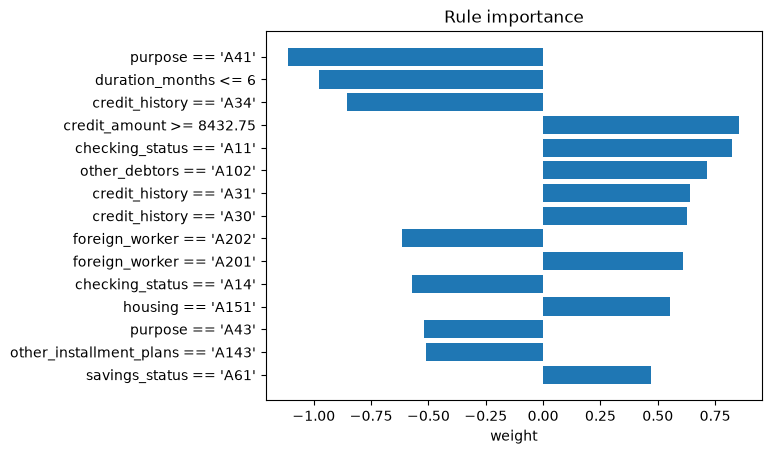

In [6]:
from flaggam.plots import plot_rule_importance, plot_shape

plot_rule_importance(est, top_n=15);

### Shape functions

`plot_shape` traces a numeric feature's fitted contribution across its range. `duration_months` and `age` are the two dominant numeric drivers in the rule table above.

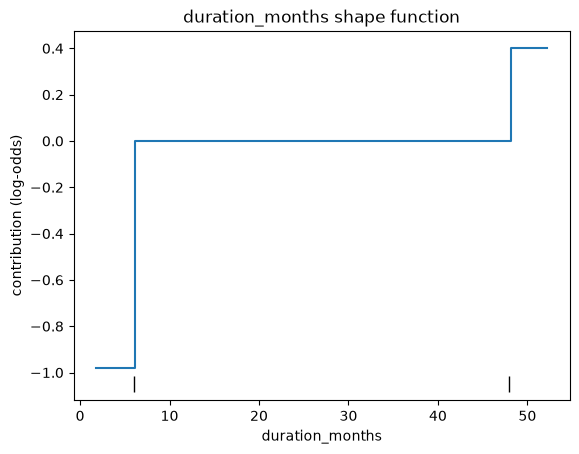

In [7]:
plot_shape(est, "duration_months");

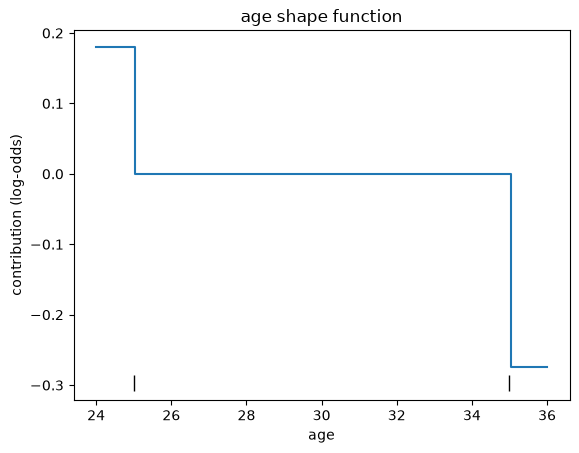

In [8]:
plot_shape(est, "age");

## 3. Reason codes

`explain()` decomposes one applicant's score into the intercept plus each fired rule's contribution — the reason codes a credit decision needs to be defensible. `plot_waterfall` renders the same decomposition as cumulative bars from intercept to total score.

In [9]:
applicant = X_test.iloc[[0]]
reasons = est.explain(applicant)
reasons.reindex(reasons["contribution"].abs().sort_values(ascending=False).index)

,row,feature,rule,value,contribution
0,0,<intercept>,<intercept>,1.0,-1.484775
1,0,credit_history,credit_history == 'A34',1.0,-0.856900
2,0,foreign_worker,foreign_worker == 'A201',1.0,0.610798
3,0,checking_status,checking_status == 'A14',1.0,-0.569723
4,0,other_installment_plans,other_installment_plans == 'A143',1.0,-0.508805
5,0,savings_status,savings_status == 'A61',1.0,0.471744
6,0,property,property == 'A121',1.0,-0.448835
7,0,housing,housing == 'A152',1.0,0.151311
8,0,purpose,purpose == 'A49',1.0,0.144557


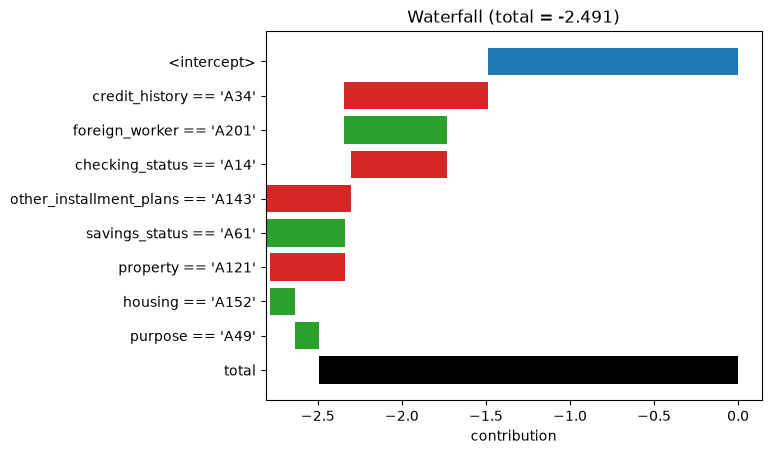

In [10]:
from flaggam.plots import plot_waterfall

plot_waterfall(est, applicant);

## 4. Calibration

AUROC measures ranking, not whether predicted probabilities match observed rates. `expected_calibration_error` (ECE) and a reliability diagram quantify that gap for the raw scores.

In [11]:
from flaggam.calibration import expected_calibration_error
from flaggam.plots import plot_reliability

ece_raw = expected_calibration_error(y_test, p_test)
print(f"raw ECE: {ece_raw:.4f}")

raw ECE: 0.0924


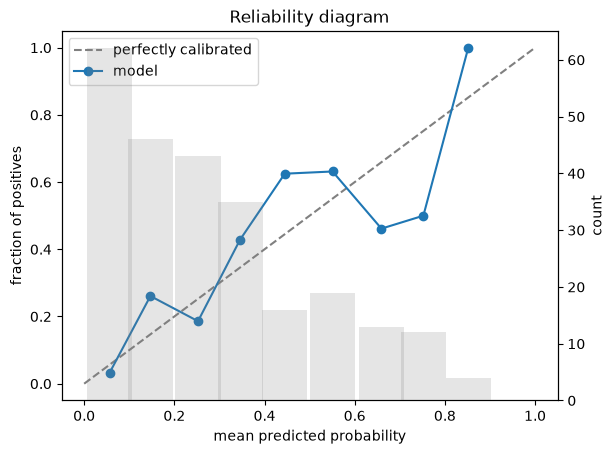

In [12]:
plot_reliability(y_test, p_test);

### Platt recalibration

`CalibratedFlagGAM` cross-fits a pooled calibrator (5-fold here) on out-of-fold predictions, then refits the base estimator on all of `X_train` before recalibrating `X_test` scores.

In [13]:
from flaggam.calibration import CalibratedFlagGAM

cal = CalibratedFlagGAM(
    FlagGAMClassifier(random_state=0), method="platt", cv=5
).fit(X_train, y_train)
p_cal = cal.predict_proba(X_test)[:, 1]
ece_cal = expected_calibration_error(y_test, p_cal)
print(f"calibrated ECE: {ece_cal:.4f}")

calibrated ECE: 0.0664


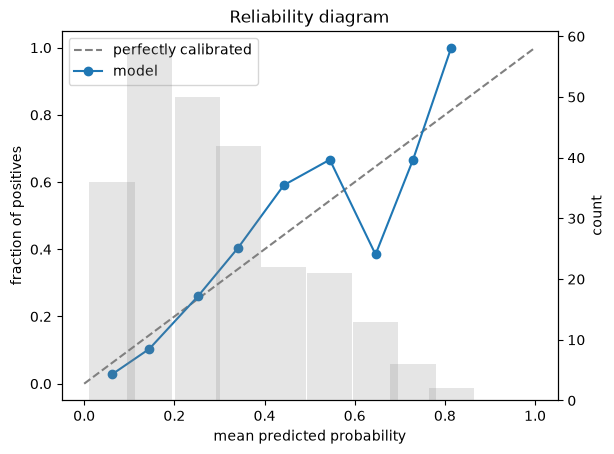

In [14]:
plot_reliability(y_test, p_cal);

## 5. Monotonicity

Longer loan durations should not *decrease* predicted risk — that is a reasonable business prior even where the discovered rule basis is noisy at the tails. `monotonic_constraints={"duration_months": 1}` forces the additive contribution of `duration_months` to be non-decreasing; the cell after refitting compares the shape function before and after.

In [15]:
est_mono = FlagGAMClassifier(
    random_state=0, monotonic_constraints={"duration_months": 1}
).fit(X_train, y_train)
p_mono = est_mono.predict_proba(X_test)[:, 1]
auroc_mono = roc_auc_score(y_test, p_mono)
print(f"unconstrained AUROC: {auroc:.4f}")
print(f"monotonic AUROC:     {auroc_mono:.4f}")

unconstrained AUROC: 0.7804
monotonic AUROC:     0.7803


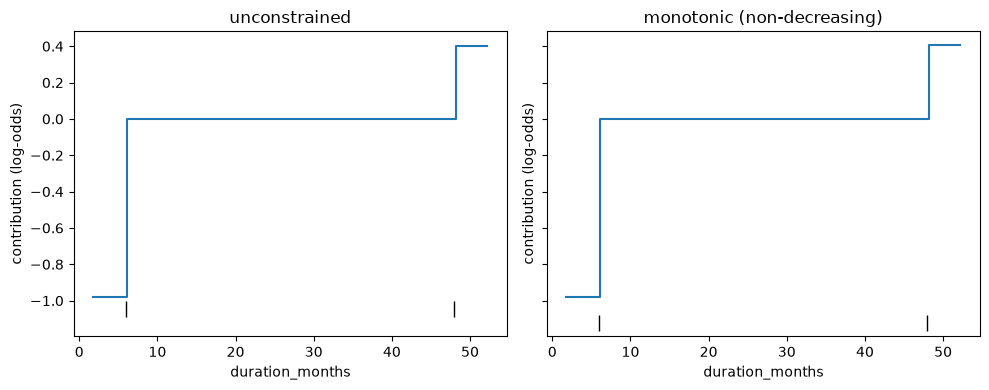

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plot_shape(est, "duration_months", ax=axes[0])
axes[0].set_title("unconstrained")
plot_shape(est_mono, "duration_months", ax=axes[1])
axes[1].set_title("monotonic (non-decreasing)")
fig.tight_layout()

## 6. Fairness & proxy audit

`personal_status_sex` (`Attribute9`) jointly encodes marital status and sex; we split it into an illustrative binary sex proxy (`A92` = female, all other codes = male, per the UCI codebook) purely to demonstrate the fairness tooling — this is not a claim that sex is (or should be) an input to a real credit decision.

In [17]:
A_test = (X_test["personal_status_sex"] == "A92").map(
    {True: "female", False: "male"}
).to_numpy()
pd.Series(A_test).value_counts()

male      167
female     83
Name: count, dtype: int64

### Group metrics

`group_metrics` reports base rate, mean predicted probability, selection rate, TPR, AUROC, and ECE per group, plus the max-minus-min gaps used as fairness diagnostics.

In [18]:
from flaggam.fairness import ProxyAudit, group_metrics
from flaggam.plots import plot_group_metrics, plot_proxy_association

gm = group_metrics(y_test.to_numpy(), p_test, A_test)
gm["by_group"]

,n,base_rate,mean_predicted,selection_rate,tpr,auroc,ece
female,83,0.373494,0.314222,0.204819,0.290323,0.761476,0.123231
male,167,0.263473,0.273766,0.185629,0.431818,0.781689,0.110655


{'demographic_parity_diff': 0.019190534593463676, 'equal_opportunity_diff': 0.1414956011730205, 'auroc_gap': 0.020212412816661307}


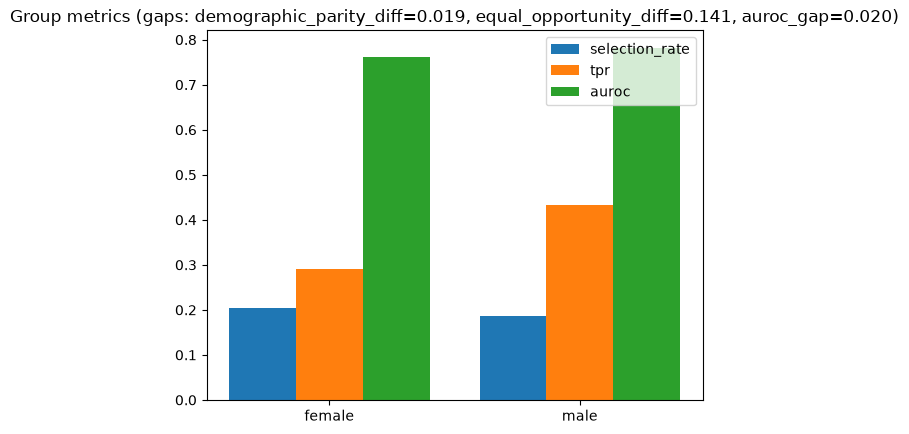

In [19]:
print(gm["gaps"])
plot_group_metrics(gm);

### Proxy audit

`ProxyAudit.report` ranks every fitted rule by its association with the protected attribute, flagging rules above a threshold as candidate proxies for `personal_status_sex`.

In [20]:
audit = ProxyAudit(est)
report = audit.report(X_test, A_test)
report.head(10)

,feature,rule,kind,association,method,flagged
0,age,age <= 25,threshold_low,0.269811,cramers_v,True
1,housing,housing == 'A151',category,0.204263,cramers_v,True
2,age,age >= 35,threshold_high,0.169684,cramers_v,False
3,employment_since,employment_since == 'A72',category,0.152334,cramers_v,False
4,savings_status,savings_status == 'A65',category,0.146113,cramers_v,False
5,other_installment_plans,other_installment_plans == 'A141',category,0.133070,cramers_v,False
6,property,property == 'A124',category,0.126391,cramers_v,False
7,housing,housing == 'A152',category,0.101072,cramers_v,False
8,purpose,purpose == 'A49',category,0.089208,cramers_v,False
9,purpose,purpose == 'A41',category,0.077368,cramers_v,False


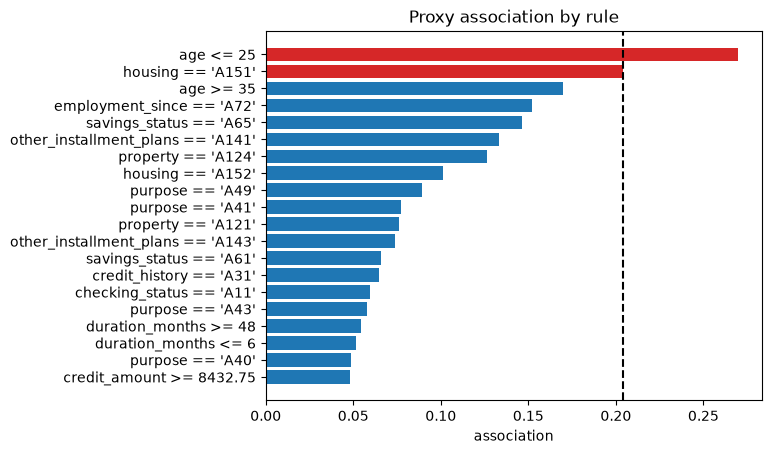

In [21]:
plot_proxy_association(report);

### Drop-proxies trade-off

`drop_proxies` refits the head with flagged rules removed and reports a before/after trade-off. Both columns are computed on the same (`X_test`, `y_test`, `A_test`) audit sample passed in — an in-sample refit comparison, not a held-out re-evaluation — so treat the AUROC/gap deltas as a diagnostic of what those rules were doing, not a generalization estimate.

In [22]:
_, tradeoff = audit.drop_proxies(X_test, y_test.to_numpy(), A_test)
tradeoff

,n_dropped,auroc_before,auroc_after,dp_diff_before,dp_diff_after
0,2,0.780419,0.857486,0.019191,0.013275


## 7. Summary

- FlagGAM fit an interpretable rule basis on German Credit with AUROC printed in §2, matching the paper-scale range for this dataset.
- `export_rules()` and `explain()` give a full audit trail from the score down to individual rule contributions and per-applicant reason codes.
- Raw probabilities were mis-calibrated (§4's raw ECE); Platt recalibration via `CalibratedFlagGAM` reduced it.
- `monotonic_constraints` enforced a non-decreasing `duration_months` shape without materially changing AUROC (§5).
- `group_metrics` and `ProxyAudit` surfaced group gaps and candidate proxy rules for the illustrative sex attribute; `drop_proxies` showed the in-sample trade-off of removing them (§6).

API reference for everything used above:
[Estimators](../../api/estimator/) ·
[Inspection](../../api/inspection/) ·
[Calibration](../../api/calibration/) ·
[Monotonic](../../api/monotonic/) ·
[Fairness](../../api/fairness/) ·
[Plots](../../api/plots/).